### pyAPES_MLM: Multi-layer soil-vegetation-atmosphere transfer model

Demo how to:
1. Set-up the model
1. Run the model
1. Retrieve the results using xarray

In [1]:
# setting path
import sys
import os

from dotenv import load_dotenv
load_dotenv()
pyAPES_main_folder = os.getenv('pyAPES_main_folder')
sys.path.append(pyAPES_main_folder)
os.chdir(pyAPES_main_folder)

### Import modules

In [2]:
from pyAPES.utils.iotools import read_results
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

resultfile = 'results/202605221600_degero_snow.nc'
# read simulation restuls to xarray dataset
results = read_results(resultfile)

In [3]:
met = f'{pyAPES_main_folder}/forcing/Degero/Degero_meteo_2021-2023.dat'
start = pd.to_datetime(str(results['date'][0].values))
end = pd.to_datetime(str(results['date'][-1].values))
meteo = pd.read_csv(met, sep=';', index_col=0, parse_dates=True)
meteo = meteo[start:end]
meteo['WTD_c'] = meteo['WTD']
meteo.loc[meteo['WTD_c'] < 0, 'WTD_c'] = 0.0
meteo['D_SNOW'] = meteo['D_SNOW']/100
meteo.loc[meteo['D_SNOW'] > 1., 'D_SNOW'] = np.nan
meteo = meteo.resample('D').mean()

binned = pd.cut(meteo['D_SNOW'], bins=100)
most_frequent_bin = binned.value_counts().idxmax()
baseval1 = round((most_frequent_bin.left + most_frequent_bin.right) / 2, 2)
baseval2 = round(meteo['D_SNOW'].median(), 2)
baseval2 = 0.05

meteo['D_SNOW_C'] = meteo['D_SNOW'] - baseval2
meteo.loc[meteo['D_SNOW_C'] < 0., 'D_SNOW_C'] = 0.
meteo.index.name = 'date'

/opt/miniconda3/envs/pyapes/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


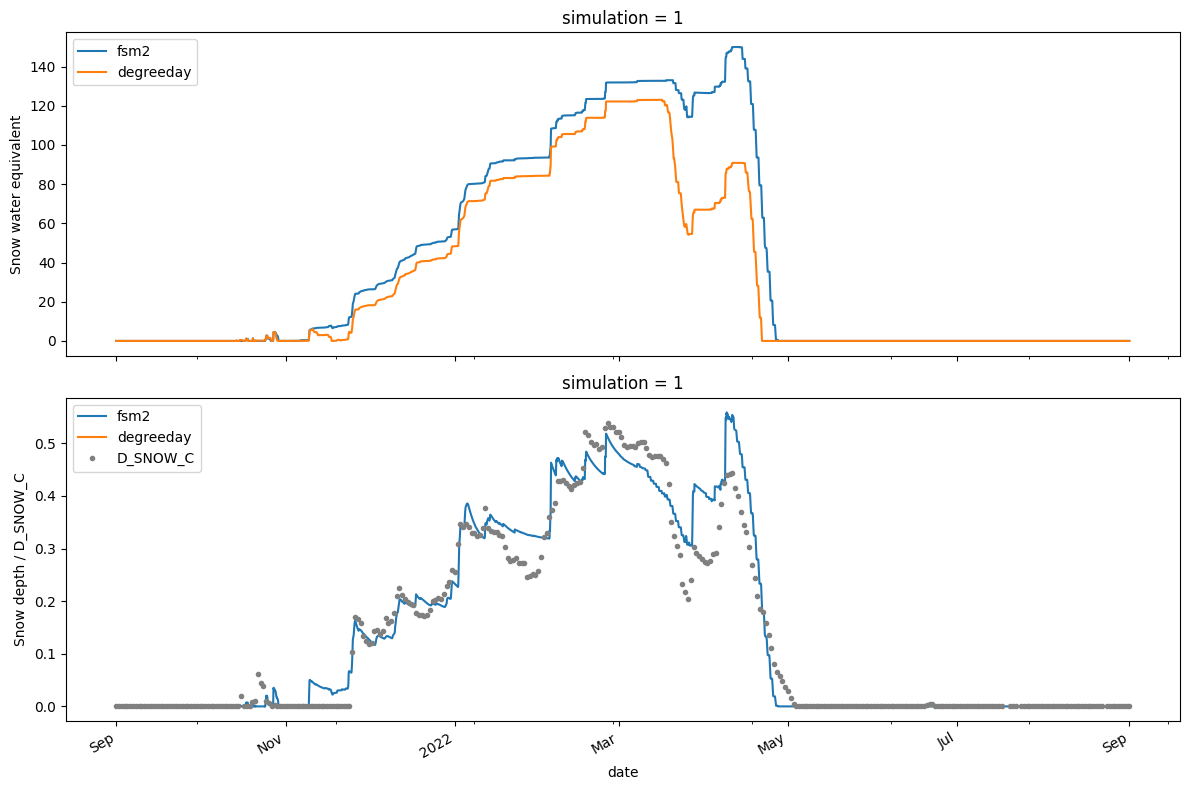

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
simulations = {0: 'fsm2', 1: 'degreeday'}

for simu, label in simulations.items():
    results['ffloor_snow_water_equivalent'].sel(simulation=simu).plot(ax=ax1, label=label)
ax1.legend(loc='upper left')
ax1.set_ylabel('Snow water equivalent')

for simu, label in simulations.items():
    results['ffloor_snow_depth'].sel(simulation=simu).plot(ax=ax2, label=label)
meteo['D_SNOW_C'].resample('D').mean().plot(ax=ax2, color='gray', marker='.', linestyle='none', label='D_SNOW_C')
ax2.set_ylabel('Snow depth / D_SNOW_C')
ax2.legend(loc='upper left')

plt.tight_layout()

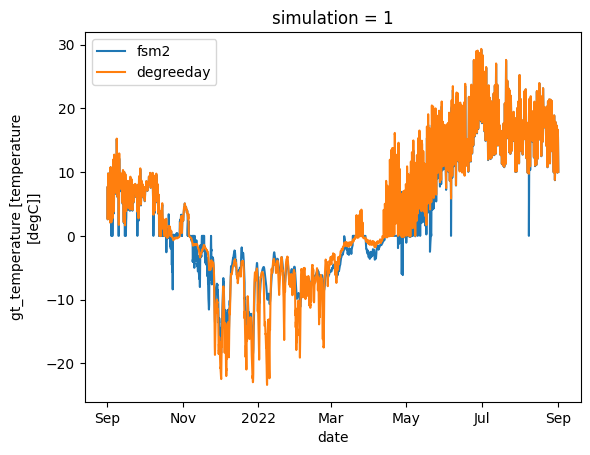

In [ ]:
simulations = {0: 'fsm2', 1: 'degreeday'}

plt.figure()
for simu, label in simulations.items():
    results['gt_temperature'].sel(simulation=simu)[:,0].plot(label=label)
plt.legend()


In [ ]:
swe = results['ffloor_snow_water_equivalent'].sel(simulation=0).sel(date=slice(plot_start, plot_end)).resample(date='1D').mean().to_dataframe()
swe

,simulation,ffloor_snow_water_equivalent
date,,
2021-11-01,0,0.000000e+00
2021-11-02,0,0.000000e+00
2021-11-03,0,0.000000e+00
2021-11-04,0,2.123485e-08
2021-11-05,0,1.236796e-02
...,...,...
2022-04-27,0,1.975973e-01
2022-04-28,0,1.737675e-08
2022-04-29,0,0.000000e+00


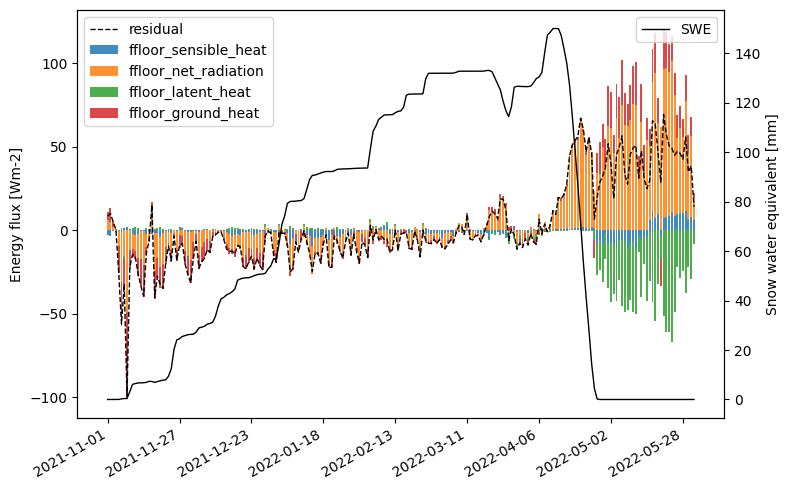

In [57]:
#Time window to plot
%matplotlib inline

plot_start = '2021-11-01'
plot_end = '2022-06-01'

flux_cols = ['ffloor_sensible_heat',
            'ffloor_net_radiation',
            'ffloor_latent_heat',
            'ffloor_ground_heat'
            ]

results_flux = results[flux_cols].sel(simulation=0).sel(date=slice(plot_start, plot_end))

results_flux['ffloor_sensible_heat'] *= -1
results_flux['ffloor_latent_heat'] *= -1

#Daily mean fluxes
results_flux = results_flux.resample(date='1D').mean().to_dataframe()[flux_cols]
swe = results['ffloor_snow_water_equivalent'].sel(simulation=0).sel(date=slice(plot_start, plot_end)).resample(date='1D').mean().to_dataframe()['ffloor_snow_water_equivalent']

results_pos = results_flux.clip(lower=0)
results_neg = results_flux.clip(upper=0)

pos = results_pos[flux_cols]
neg = results_neg[flux_cols]

idx = pos.index.union(neg.index)
pos = pos.reindex(idx).fillna(0.0)
neg = neg.reindex(idx).fillna(0.0)

residual = results_flux.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(idx))
width = 0.7

pos_bottom = np.zeros(len(idx))
neg_bottom = np.zeros(len(idx))

cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
colors = {c: cycle[i % len(cycle)] for i, c in enumerate(flux_cols)}

for col in flux_cols:
    y = pos[col].to_numpy()
    ax.bar(x, y, bottom=pos_bottom, width=width, alpha=0.85, color=colors[col], label=col)
    pos_bottom += y

for col in flux_cols:
    y = neg[col].to_numpy()
    ax.bar(x, y, bottom=neg_bottom, width=width, alpha=0.85, color=colors[col])
    neg_bottom += y

ax.plot(x, residual.reindex(idx).to_numpy(), color='black', linewidth=1.0, linestyle='--', label='residual')

ax.set_ylabel("Energy flux [Wm-2]")
ax.legend(loc="upper left")

ax2 = ax.twinx()
ax2.plot(x, swe.to_numpy(), linewidth=1.0, color='black', linestyle='-', label="SWE")
ax2.set_ylabel("Snow water equivalent [mm]")
ax2.legend(loc="upper right")

tick_step = max(1, len(idx) // 8)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in idx[::tick_step]], rotation=30, ha="right")

plt.tight_layout()
#filename = f'/Users/jpnousu/Library/CloudStorage/OneDrive-Luonnonvarakeskus/pyAPES_figs/ebal_{snowmod}_2_2026.png'
#plt.savefig(filename, dpi=300, bbox_inches="tight")